In [1]:
import gym
import numpy as np
import networkx as nx
from gym import spaces

class CordonDesignEnv(gym.Env):
    """
    状态 = one-hot当前节点 + 已访问mask + 剩余步数
    动作 = [所有一度邻居, 所有二度邻居, 终止]
    """
    def __init__(self, graph: nx.Graph, max_steps: int = 8, od_pairs=None, edge_features=('free_time', 'capacity')):
        super().__init__()
        self.graph = graph
        self.max_steps = max_steps
        self.nodes = list(graph.nodes())
        self.node2idx = {n: i for i, n in enumerate(self.nodes)}
        self.num_nodes = len(self.nodes)
        self.edge_features = edge_features

        # OD对、全局特征
        self.od_pairs = od_pairs if od_pairs is not None else []
        self.global_features = self._get_global_features()

        # 状态空间 = one-hot当前节点 + 访问mask + 剩余步数(归一化)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, 
            shape=(self.num_nodes * 2 + 1,),
            dtype=np.float32
        )

        # 动作空间 = 所有邻居 + 所有2-hop邻居 + 终止（在每步动态生成）
        # 为兼容RL训练，这里先按最大可能邻居数做pad，实际用action_mask约束
        self.max_1hop = max([len(list(graph.neighbors(n))) for n in self.nodes])
        self.max_2hop = max([len(self._get_2hop_neighbors(n)) for n in self.nodes])
        #self.action_space = spaces.Discrete(self.max_1hop + self.max_2hop + 1)  # +1 for stop
        self.action_space = spaces.Discrete(self.max_1hop + 1)  # +1 for stop

    def _get_global_features(self):
        # OD, 节点位置, 节点邻接矩阵, edge的free_time and capacity
        # extra OD matrix should be considered as a global feature
        feat = {}
        for name in self.edge_features:
            values = [self.graph.edges[e].get(name, 0.0) for e in self.graph.edges()]
            #### 直接以graph作为全局feature
            feat[name] = np.mean(values)
        return feat

    def _get_2hop_neighbors(self, node):
        # 返回所有二度邻居（去重/去当前节点/去一度邻居）
        hop1 = set(self.graph.neighbors(node))
        hop2 = set()
        for n in hop1:
            hop2.update(set(self.graph.neighbors(n)))
        hop2 -= hop1
        hop2.discard(node)
        return list(hop2)

    def reset(self):
        self.cur_node = np.random.choice(self.nodes)
        self.traj = [self.cur_node]
        self.visited_mask = np.zeros(self.num_nodes, dtype=np.float32)
        self.visited_mask[self.node2idx[self.cur_node]] = 1.0
        self.step_count = 0
        self.done = False
        return self._get_state()

    def _get_state(self):
        # state = [one-hot当前点] + [visited mask] + [剩余步数/最大步长]
        cur_onehot = np.zeros(self.num_nodes, dtype=np.float32)
        cur_onehot[self.node2idx[self.cur_node]] = 1.0
        remain_steps = np.array([1.0 - self.step_count / self.max_steps], dtype=np.float32)
        state = np.concatenate([cur_onehot, self.visited_mask, remain_steps])
        return state

    def _get_action_candidates(self):
        # 每步输出所有合法action（用于mask/policy输出）
        hop1 = list(self.graph.neighbors(self.cur_node))
        # No 2 neighborhoods
        #hop2 = self._get_2hop_neighbors(self.cur_node)
        #candidates = hop1 + hop2
        candidates = hop1
        return candidates

    def step(self, action):
        if self.done:
            raise ValueError("Episode already done, please reset.")

        candidates = self._get_action_candidates()
        n1, n2 = len(list(self.graph.neighbors(self.cur_node))), len(self._get_2hop_neighbors(self.cur_node))
        stop_idx = n1
        #stop_idx = n1 + n2  # 终止动作的索引

        if action == stop_idx:
            self.done = True
        else:
            if action < len(candidates):
                next_node = candidates[action]
                self.cur_node = next_node
                self.traj.append(next_node)
                self.visited_mask[self.node2idx[next_node]] = 1.0
                self.step_count += 1
                if self.step_count >= self.max_steps:
                    self.done = True
            else:
                raise ValueError(f"Invalid action: {action}")

        # 奖励设计：中间reward恒为0，只有done时奖励
        if self.done:
            # 奖励 = -frank_wolfe目标 或用其它函数
            reward = 0.0
            info = {'traj': self.traj}
        else:
            reward = 0.0
            info = {}

        return self._get_state(), reward, self.done, info

    def render(self, mode='human'):
        print(f"Trajectory: {self.traj}")

    def get_action_mask(self):
        # 输出当前动作mask（1为可选，0为不可选），供策略/agent使用
        candidates = self._get_action_candidates()
        mask = np.zeros(self.action_space.n, dtype=np.float32)
        mask[:len(candidates)] = 1.0
        mask[len(candidates)] = 1.0  # stop始终可选
        return mask

    @property
    def current_trajectory(self):
        return self.traj

    @property
    def current_node(self):
        return self.cur_node


In [2]:
import matplotlib.pyplot as plt

def plot_cordon_traj(G, traj):
    pos = {n: G.nodes[n]['pos'] for n in G.nodes()}
    traj_set = set(traj)
    node_colors = ['red' if n in traj_set else 'blue' for n in G.nodes()]
    plt.figure(figsize=(6, 6))
    nx.draw_networkx_edges(G, pos, alpha=0.4)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400)
    nx.draw_networkx_labels(G, pos, font_size=12)
    # 绘制轨迹连线
    if len(traj) > 1:
        pts = [pos[n] for n in traj]
        plt.plot([p[0] for p in pts], [p[1] for p in pts], color='red', linewidth=3, alpha=0.7, zorder=10)
    plt.axis('off')
    plt.title("Cordon Node Trajectory")
    plt.show()


step: 1, action: 0, node: 1, done: False
step: 2, action: 0, node: 0, done: False
step: 3, action: 1, node: 1, done: False
step: 3, action: 3, node: 1, done: True
轨迹节点: [2, 1, 0, 1]


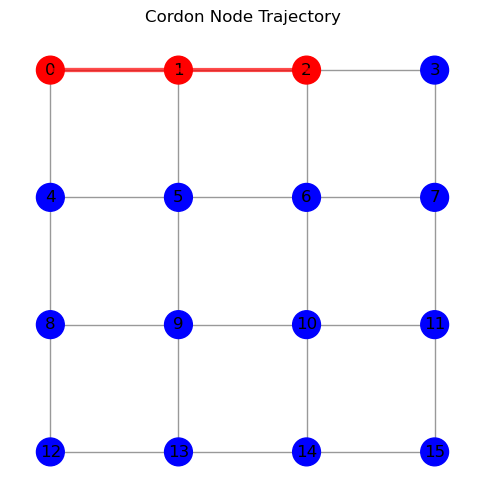

In [3]:
import networkx as nx

def build_grid_graph_with_pos(n_rows=4, n_cols=4):
    G = nx.grid_2d_graph(n_rows, n_cols)
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")  # 节点编号0~15
    pos_map = {}
    for idx, (i, j) in enumerate([(i, j) for i in range(n_rows) for j in range(n_cols)]):
        pos_map[idx] = (j, -i)   # 横轴j，纵轴-i（y反转让(0,0)在左上）
        G.nodes[idx]['pos'] = (j, -i)
    # 添加edge特征（随便生成）
    for u, v in G.edges():
        G.edges[u, v]['free_time'] = np.random.uniform(10, 50)
        G.edges[u, v]['capacity'] = np.random.uniform(100, 500)
    return G, pos_map

G, pos_map = build_grid_graph_with_pos(4, 4)
# 初始化环境
env = CordonDesignEnv(G, max_steps=8)

state = env.reset()
done = False
while not done:
    mask = env.get_action_mask()
    action = np.random.choice(np.where(mask == 1)[0])  # 随机合法动作
    next_state, reward, done, info = env.step(action)
    print(f"step: {env.step_count}, action: {action}, node: {env.cur_node}, done: {done}")

if 'traj' in info:
    print("轨迹节点:", info['traj'])
if 'traj' in info:
    plot_cordon_traj(env.graph, info['traj'])

# Generate training data

In [327]:
import torch
from torch_geometric.data import Data

def build_pyg_data_with_2hop_and_terminal(links, coords, od, 
                                          two_hop_attr=(-1, -1), 
                                          virtual_attr=(-1, -1), 
                                          virtual_pos_offset=100.0):
    # Step 1: 编号映射（因为PyG要求编号从0连续）
    nodes = set()
    for u, v, *_ in links:
        nodes.add(u)
        nodes.add(v)
    for u, v in od.keys():
        nodes.add(u)
        nodes.add(v)
    n_nodes = len(nodes)
    nodes = sorted(list(nodes))
    node2idx = {n: i for i, n in enumerate(nodes)}
    idx2node = {i: n for n, i in node2idx.items()}
    
    
    new_links = []
    new_coords = dict()
    new_ods = dict()

    # Step 2: 节点特征 [x, y]
    pos = torch.zeros((n_nodes, 2), dtype=torch.float)
    for n, i in node2idx.items():
        pos[i] = torch.tensor(coords[n], dtype=torch.float)
        new_coords[i] = coords[n] 

    # Step 3: 真实一度邻居边
    edge_list = []
    edge_attr_list = []
    neighbor_dict = {i: set() for i in range(n_nodes)}
    edge_set = set()
    for u, v, free_time, capacity in links:
        i, j = node2idx[u], node2idx[v]
        edge_list.append([i, j])
        edge_attr_list.append([free_time, capacity])
        neighbor_dict[i].add(j)
        edge_set.add((i, j))  # 用于后续判重
        new_links.append([i, j, free_time, capacity])

    '''
    # Step 4: 二度邻居（未直接连接的才加）
    for i in range(n_nodes):
        one_hop = neighbor_dict[i]
        two_hop = set()
        for j in one_hop:
            two_hop |= neighbor_dict[j]
        two_hop -= one_hop
        two_hop.discard(i)
        for j in two_hop:
            if (i, j) not in edge_set:
                edge_list.append([i, j])
                edge_attr_list.append(list(two_hop_attr))
                edge_set.add((i, j))  # 防止重复添加
    '''
    '''
    # Step 5: 虚拟终止节点
    virtual_idx = n_nodes
    # 虚拟节点pos放远处
    pos_min = pos.min(dim=0)[0]
    pos_max = pos.max(dim=0)[0]
    vt_pos = pos_max + virtual_pos_offset
    pos = torch.cat([pos, vt_pos[None, :]], dim=0)

    # 虚拟节点与所有节点一度相连
    for i in range(n_nodes):
        edge_list.append([i, virtual_idx])
        edge_attr_list.append(list(virtual_attr))
        edge_list.append([virtual_idx, i])
        edge_attr_list.append(list(virtual_attr))
    '''
    

    # Step 6: OD矩阵
    od_mat = torch.zeros((n_nodes, n_nodes), dtype=torch.float)  # +1支持终止节点，终止节点OD都为0
    for (u, v), d in od.items():
        if u in node2idx and v in node2idx:
            od_mat[node2idx[u], node2idx[v]] = d
            new_ods[(node2idx[u],node2idx[v])] = d
    # Step 7: 打包PyG Data
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float)

    #idx2node[n_nodes] = 100
    #idx2node[n_nodes] = n_nodes + 1

    pyg_data = Data(
        x=pos,                   # 节点特征 [n_nodes+1, 2]
        edge_index=edge_index,   # [2, E]
        edge_attr=edge_attr,     # [E, 2]
    )
    pyg_data.od_matrix = od_mat         # [n_nodes+1, n_nodes+1]
    pyg_data.idx2node = idx2node        # 便于还原原始编号

    return pyg_data, new_coords, new_links, new_ods

def intersection_graph(pyg):

    device = pyg.edge_index.device if hasattr(pyg, "edge_index") else torch.device("cpu")
    N = pyg.x.size(0)  
    src_all, dst_all = pyg.edge_index[0], pyg.edge_index[1]
    virtual_idx = -1
    real_mask = (src_all != virtual_idx) & (dst_all != virtual_idx)
    #real_mask = src_all & dst_all
    src = src_all[real_mask]
    dst = dst_all[real_mask]

    if src.numel() > 0:
        u = torch.minimum(src, dst)
        v = torch.maximum(src, dst)
        canon = torch.stack([u, v], dim=1)                           # [E_real, 2]
        uniq_uv, _ = torch.unique(canon, dim=0, return_inverse=True) # uniq_uv: [M,2]
        M = uniq_uv.size(0)
    else:
        uniq_uv = torch.empty((0, 2), dtype=torch.long, device=device)
        M = 0

    inter_idx2node = dict()
    if M > 0:
        for i in range(M):
            u_i = int(uniq_uv[i, 0].item())
            v_i = int(uniq_uv[i, 1].item())
            #orig_u = pyg.idx2node[u_i]
            #orig_v = pyg.idx2node[v_i]
            inter_idx2node[i] = (u_i, v_i)


    incident = [[] for _ in range(N)]
    for k in range(M):
        a = int(uniq_uv[k, 0].item())
        b = int(uniq_uv[k, 1].item())
        incident[a].append(k)
        incident[b].append(k)

    Ls, Ld = [], []
    #print(incident)
    for nid in range(N):
        inc = incident[nid]
        d = len(inc)
        if d >= 2:
            for i in range(d):
                for j in range(i + 1, d):
                    ei, ej = inc[i], inc[j]
                    Ls.extend([ei, ej])
                    Ld.extend([ej, ei])
    intersection_virtual_idx = M
    inter_idx2node[M] = (-1, M)
    if M > 0:
        for k in range(M):
            Ls.extend([k, intersection_virtual_idx])
            Ld.extend([intersection_virtual_idx, k])
    if len(Ls) == 0:
        intersection_edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
    else:
        intersection_edge_index = torch.tensor([Ls, Ld], dtype=torch.long, device=device)

    # 5) 原地挂到 pyg

    pyg.intersection_edge_index = intersection_edge_index
    pyg.intersection_idx2node = inter_idx2node
    return pyg


# =======================
# 用法示例
if __name__ == "__main__":
    links = [ 
        (1, 12, 100, 700), (12, 1,  70, 700),
        (5,  1,  45, 900), (1,  5,  29, 900),
        (12, 6, 40,  300), (6, 12, 23, 300),
        (12, 8, 80,  700), (8, 12, 51, 700),
        (5,  9, 26, 600),  (9,  5,  18, 900),
        (5,  4, 25, 700),  (4,  5,  13, 700),
        (5,  6, 19, 800),  (6,  5,  36, 800),
        (4,  9, 45, 900),  (9,  4,  26, 600),
        (6,  10, 20, 500), (10, 6, 16, 500),
        (6,  7, 53, 900),  (7, 6, 88, 900),
        (7,  8, 27, 300),  (8,  7, 59, 300),
        (7, 11, 32, 400),  (11, 7, 36, 400),
        (8, 2, 35, 700),   (2, 8,  98, 700),
        (9, 10, 43, 700),  (10, 9, 75, 700),
        (10,11, 33, 700),  (11,10, 60, 700),
        (11, 2, 50, 700),  (2, 11, 83, 700),
        (9, 13, 56, 600),  (13, 9, 28, 600),
        (3, 11, 67, 700),  (11, 3, 41, 700),
        (3, 13, 29, 700),  (13, 3, 53, 700)
    ]
    od = {
        (6, 3): 1000,
        (10, 2): 500,
        (5, 2): 480,
        (9, 3): 520
    }
    coords = {
        1:(1,3), 2:(4,1), 3:(3,0),
        4:(0,2), 5:(1,2), 6:(2,2),
        7:(3,2), 8:(4,2), 9:(1,1),
        10:(2,1),11:(3,1),12:(2,3),13:(2,0)
    }
    pyg_data, new_coords, new_links, new_od = build_pyg_data_with_2hop_and_terminal(links_SF, coords_SF, od_SF)
    intersection_graph(pyg_data)
    print(pyg_data)
    print("节点数:", pyg_data.x.shape[0])
    print("边数:", pyg_data.intersection_edge_index)
    print(pyg_data.edge_index.size(1))
    #print("OD矩阵shape:", pyg_data.od_matrix)
    print("前5条边：")
    print(pyg_data.edge_index[:, :5])
    print(pyg_data.edge_attr[:5])
    #print(new_coords, new_links, new_od)

Data(
  x=[24, 2],
  edge_index=[2, 76],
  edge_attr=[76, 2],
  od_matrix=[24, 24],
  idx2node={
    0=1,
    1=2,
    2=3,
    3=4,
    4=5,
    5=6,
    6=7,
    7=8,
    8=9,
    9=10,
    10=11,
    11=12,
    12=13,
    13=14,
    14=15,
    15=16,
    16=17,
    17=18,
    18=19,
    19=20,
    20=21,
    21=22,
    22=23,
    23=24,
  },
  intersection_edge_index=[2, 254],
  intersection_idx2node={
    0=[2],
    1=[2],
    2=[2],
    3=[2],
    4=[2],
    5=[2],
    6=[2],
    7=[2],
    8=[2],
    9=[2],
    10=[2],
    11=[2],
    12=[2],
    13=[2],
    14=[2],
    15=[2],
    16=[2],
    17=[2],
    18=[2],
    19=[2],
    20=[2],
    21=[2],
    22=[2],
    23=[2],
    24=[2],
    25=[2],
    26=[2],
    27=[2],
    28=[2],
    29=[2],
    30=[2],
    31=[2],
    32=[2],
    33=[2],
    34=[2],
    35=[2],
    36=[2],
    37=[2],
    38=[2],
  }
)
节点数: 24
边数: tensor([[ 0,  1,  0,  2,  1,  3,  1,  4,  3,  4,  3,  5,  3,  6,  5,  6,  5,  7,
          5,  8,  7,  8,  2,  7,  

# Network

In [55]:
import torch
from torch import nn
import torch.nn.functional as F
import torch_geometric.nn as gnn

### from deep aco
### to do: od matrix input and embedding

class EmbNet(nn.Module):
    def __init__(self, depth=6, node_dim=2, edge_dim=2, units=32, act_fn='silu', agg_fn='mean'):
        super().__init__()
        # expected to accpet a OD parameters
        self.depth = depth
        self.units = units
        self.act_fn = getattr(F, act_fn)
        self.agg_fn = getattr(gnn, f'global_{agg_fn}_pool')
        # 节点和边升维
        self.v_lin0 = nn.Linear(node_dim, units) # 节点坐标
        self.e_lin0 = nn.Linear(edge_dim, units) # 边的free-time + capacity 可能还有长度
        #self.od_lin0 = nn.Linear(od_dim, units)

        # ==== 新增：OD 注入的轻量头 ====
        self.od_node_lin0 = nn.Linear(2, units)
        self.od_edge_lin0 = nn.Linear(1, units)

        
        # GNN多分支结构
        self.v_lins1 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_lins2 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_lins3 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_lins4 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_bns = nn.ModuleList([gnn.BatchNorm(units) for _ in range(depth)])
        self.e_lins0 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.e_bns = nn.ModuleList([gnn.BatchNorm(units) for _ in range(depth)])

    def forward(self, x, edge_index, edge_attr, od_matrix=None):
        x = self.v_lin0(x)
        x = self.act_fn(x)

        w = self.e_lin0(edge_attr)
        w = self.act_fn(w)

        # 2) OD 注入（仅当提供 od_matrix 时启用）
        if od_matrix is not None:
            od = od_matrix.to(device)
            N = x.size(0)
            if od.dim() != 2 or od.size(0) != N or od.size(1) != N:
                raise ValueError(f"OD shape mismatch: expect [{N},{N}], got {tuple(od.shape)}")

            nz_mask = (od > 0)
            od_tr = od.clone()
            od_tr[nz_mask] = torch.log1p(od_tr[nz_mask])

            od_row = od_tr.sum(dim=1, keepdim=True)
            od_col = od_tr.sum(dim=0, keepdim=True).t()
            od_node_feat = torch.cat([od_row, od_col], dim=1)  # [N,2]

            for j in (0, 1):
                col = od_node_feat[:, j]
                mask = (col != 0)
                if mask.any():
                    mu = col[mask].mean()
                    sigma = col[mask].std().clamp_min(EPS)
                    od_node_feat[:, j] = (col - mu) / sigma
                else:
                    od_node_feat[:, j] = 0.0

            x = x + self.act_fn(self.od_node_lin0(od_node_feat))

            src, dst = edge_index[0], edge_index[1]
            od_e = od_tr[src, dst].unsqueeze(1)  # [E,1]

            if (od_e != 0).any():
                mu_e = od_e[od_e != 0].mean()
                std_e = od_e[od_e != 0].std().clamp_min(EPS)
                od_e = (od_e - mu_e) / std_e
            else:
                od_e = torch.zeros_like(od_e)

            w = w + self.act_fn(self.od_edge_lin0(od_e))

        for i in range(self.depth):
            x0 = x
            x1 = self.v_lins1[i](x0)
            x2 = self.v_lins2[i](x0)
            x3 = self.v_lins3[i](x0)
            x4 = self.v_lins4[i](x0)

            w0 = w
            w1 = self.e_lins0[i](w0)
            w2 = torch.sigmoid(w0)
            
            x = x0 + self.act_fn(self.v_bns[i](x1 + self.agg_fn(w2 * x2[edge_index[1]], edge_index[0])))
            w = w0 + self.act_fn(self.e_bns[i](w1 + x3[edge_index[0]] + x4[edge_index[1]]))
        return w  # [num_edges, units]

class MLP(nn.Module):
    def __init__(self, units_list, act_fn):
        super().__init__()
        self.units_list = units_list
        self.depth = len(self.units_list) - 1
        self.act_fn = getattr(F, act_fn)
        self.lins = nn.ModuleList([nn.Linear(self.units_list[i], self.units_list[i + 1]) for i in range(self.depth)])
    def forward(self, x):
        for i in range(self.depth):
            x = self.lins[i](x)
            if i < self.depth - 1:
                x = self.act_fn(x)
            else:
                x = torch.sigmoid(x)  # 输出归一化到(0,1)
        return x

class ParNet(MLP):
    def __init__(self, depth=3, units=32, preds=1, act_fn='silu'):
        self.units = units
        self.preds = preds
        super().__init__([units] * depth + [preds], act_fn)
    def forward(self, x):
        return super().forward(x).squeeze(dim = -1)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb_net = EmbNet()
        self.par_net_heu = ParNet()
    def forward(self, pyg):
        x, edge_index, edge_attr, od_mat = pyg.x, pyg.edge_index, pyg.edge_attr, pyg.od_matrix
        emb = self.emb_net(x, edge_index, edge_attr, od_matrix=od_mat)
        heu = self.par_net_heu(emb)
        return heu  # [num_edges]
        
    def freeze_gnn(self):
        for param in self.emb_net.parameters():
            param.requires_grad = False

    @staticmethod
    def reshape(pyg, vector):
        '''把edge向量转回邻接矩阵'''
        # 修改为交集图的邻接矩阵 因此  input dimension要修改为交际图的node list ---
        n_nodes = pyg.x.shape[0]
        device = pyg.x.device
        matrix = torch.zeros(size=(n_nodes, n_nodes), device=device)
        matrix[pyg.edge_index[0], pyg.edge_index[1]] = vector
        return matrix


In [333]:
import torch 
from torch import nn
import torch.nn.functional as F
import torch_geometric.nn as gnn

EPS = 1e-6  # ==== ADD: 数值安全

class EmbNet(nn.Module):
    def __init__(self, depth=6, node_dim=2, edge_dim=2, units=32, act_fn='silu', agg_fn='mean'):
        super().__init__()
        self.depth = depth
        self.units = units
        self.act_fn = getattr(F, act_fn)
        self.agg_fn = getattr(gnn, f'global_{agg_fn}_pool')
        self.v_lin0 = nn.Linear(node_dim, units)
        self.e_lin0 = nn.Linear(edge_dim, units)

        # OD input ----拆分为edge_特征 和 node 特征
        self.od_node_lin0 = nn.Linear(2, units)
        self.od_edge_lin0 = nn.Linear(1, units)

        self.v_lins1 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_lins2 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_lins3 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_lins4 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.v_bns = nn.ModuleList([gnn.BatchNorm(units) for _ in range(depth)])
        self.e_lins0 = nn.ModuleList([nn.Linear(units, units) for _ in range(depth)])
        self.e_bns = nn.ModuleList([gnn.BatchNorm(units) for _ in range(depth)])

    def forward(self, x, edge_index, edge_attr, od_matrix=None):
        device = x.device  # ==== FIX: 你原来这里没定义 device
        x = self.v_lin0(x)
        x = self.act_fn(x)
        w = self.e_lin0(edge_attr)
        w = self.act_fn(w)

        if od_matrix is not None:
            od = od_matrix.to(device)
            N = x.size(0)
            if od.dim() != 2 or od.size(0) != N or od.size(1) != N:
                raise ValueError(f"OD shape mismatch: expect [{N},{N}], got {tuple(od.shape)}")

            nz_mask = (od > 0)
            od_tr = od.clone()
            od_tr[nz_mask] = torch.log1p(od_tr[nz_mask])

            od_row = od_tr.sum(dim=1, keepdim=True)
            od_col = od_tr.sum(dim=0, keepdim=True).t()
            od_node_feat = torch.cat([od_row, od_col], dim=1)

            for j in (0, 1):
                col = od_node_feat[:, j]
                mask = (col != 0)
                if mask.any():
                    mu = col[mask].mean()
                    sigma = col[mask].std().clamp_min(EPS)
                    od_node_feat[:, j] = (col - mu) / sigma
                else:
                    od_node_feat[:, j] = 0.0

            x = x + self.act_fn(self.od_node_lin0(od_node_feat))

            src, dst = edge_index[0], edge_index[1]
            od_e = od_tr[src, dst].unsqueeze(1)
            if (od_e != 0).any():
                mu_e = od_e[od_e != 0].mean()
                std_e = od_e[od_e != 0].std().clamp_min(EPS)
                od_e = (od_e - mu_e) / std_e
            else:
                od_e = torch.zeros_like(od_e)
            w = w + self.act_fn(self.od_edge_lin0(od_e))

        for i in range(self.depth):
            x0 = x
            x1 = self.v_lins1[i](x0)
            x2 = self.v_lins2[i](x0)
            x3 = self.v_lins3[i](x0)
            x4 = self.v_lins4[i](x0)

            w0 = w
            w1 = self.e_lins0[i](w0)
            w2 = torch.sigmoid(w0)
            x = x0 + self.act_fn(self.v_bns[i](x1 + self.agg_fn(w2 * x2[edge_index[1]], edge_index[0])))
            w = w0 + self.act_fn(self.e_bns[i](w1 + x3[edge_index[0]] + x4[edge_index[1]]))
        return w  # [E_dir, units]

class MLP(nn.Module):
    def __init__(self, units_list, act_fn):
        super().__init__()
        self.units_list = units_list
        self.depth = len(self.units_list) - 1
        self.act_fn = getattr(F, act_fn)
        self.lins = nn.ModuleList([nn.Linear(self.units_list[i], self.units_list[i + 1]) for i in range(self.depth)])
    def forward(self, x):
        for i in range(self.depth):
            x = self.lins[i](x)
            if i < self.depth - 1:
                x = self.act_fn(x)
            else:
                x = torch.sigmoid(x)
        return x

class ParNet(MLP):
    def __init__(self, depth=3, units=32, preds=1, act_fn='silu'):
        self.units = units
        self.preds = preds
        super().__init__([units] * depth + [preds], act_fn)
    def forward(self, x):
        return super().forward(x).squeeze(dim=-1)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb_net = EmbNet()
        self.par_net_heu = ParNet()
        units = self.emb_net.units
        #self.intersection_virtual_emb = nn.Parameter(torch.zeros(1, units))
        self.intersection_virtual_emb = nn.Parameter(torch.full((1, units), 0.01))#
        nn.init.normal_(self.intersection_virtual_emb, mean=0.0, std=0.02)
        self.intersection_virtual_emb.requires_grad = False  # 冻结
        self.apply(self._init_weights)
    ''''''
    @staticmethod
    def _init_weights(m: nn.Module):
        if isinstance(m, nn.Linear):
            if m.out_features == 1:
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('sigmoid'))
            else:
                nn.init.kaiming_uniform_(m.weight, a=0.0, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        if isinstance(m, nn.BatchNorm1d):
            if m.weight is not None:
                nn.init.ones_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
            return
        if isinstance(m, gnn.BatchNorm):
            bn = getattr(m, "bn", None)
            if bn is not None:
                if getattr(bn, "weight", None) is not None:
                    nn.init.ones_(bn.weight)
                if getattr(bn, "bias", None) is not None:
                    nn.init.zeros_(bn.bias)
            return
    def forward(self, pyg):
        """
        仍然只吃原图：
          pyg.x, pyg.edge_index, pyg.edge_attr, pyg.od_matrix
        但在末端使用：
          pyg.intersection_edge_index, pyg.intersection_idx2node
        来生成交集图的边分数，再 reshape 成 M×M。
        """
        x, edge_index, edge_attr, od_mat = pyg.x, pyg.edge_index, pyg.edge_attr, getattr(pyg, 'od_matrix', None)

        # 1) 原图有向边嵌入 [E_dir, units]
        emb = self.emb_net(x, edge_index, edge_attr, od_matrix=od_mat)
        #print(emb.shape) # [real edge(Digraph), unit]

        pair2line = {}  # (orig_u, orig_v) 无向对 -> line_id
        inter_map = pyg.intersection_idx2node  # (编号： 真实边)
        #print('original index:', inter_map)
        M_total = len(inter_map)               # 注意：这里已包含交集虚拟节点
        for lid, pair in inter_map.items():
            a, b = pair
            if a <= b:
                key = (a, b)
            else:
                key = (b, a)
            pair2line[key] = int(lid)

        idx2node = getattr(pyg, 'idx2node', {i: int(i) for i in range(x.size(0))})
        # intersection graph的虚拟节点编号
        inter_virt = getattr(pyg, 'intersection_virtual_idx', M_total - 1)

        inter_edge_index = pyg_data.intersection_edge_index
        # 真实边的起点、重点 size 38, 1
        src_all, dst_all = edge_index[0], edge_index[1]
        E_dir = src_all.numel()
        dir2line_idx = torch.empty(E_dir, dtype=torch.long, device=emb.device) # 38,1 

        for k in range(E_dir):
            oi = int(src_all[k].item())
            oj = int(dst_all[k].item())
            #oi = idx2node[i]
            #oj = idx2node[j]
            key = (oi, oj) if oi <= oj else (oj, oi)
            lid = pair2line.get(key, inter_virt)  # 查不到就映射到交集虚拟节点
            dir2line_idx[k] = lid

        # 3) 对相同 line_id 的 emb 做平均，得到交集图节点嵌入 H[M_total, units]
        units = emb.size(1)
        H = torch.zeros(M_total, units, device=emb.device, dtype=emb.dtype)
        cnt = torch.zeros(M_total, 1, device=emb.device, dtype=emb.dtype)
        H.index_add_(0, dir2line_idx, emb)
        cnt.index_add_(0, dir2line_idx, torch.ones_like(dir2line_idx, dtype=emb.dtype).unsqueeze(1))
        H = H / (cnt + EPS)

        #print(cnt[inter_virt].item())
        if cnt[inter_virt].item() == 0.0:
            H[inter_virt] = self.intersection_virtual_emb.squeeze(0) 
        else:
            H[inter_virt] = 0.5 * (H[inter_virt] + self.intersection_virtual_emb.squeeze(0) )

        # 4) 在交集图的“边”上打分
        edge_index_L = pyg.intersection_edge_index.to(emb.device)  # [2, E_L] # 
        print(pyg.intersection_idx2node)
        if edge_index_L.numel() == 0:
            heu_vec = torch.empty(0, device=emb.device)
            heu_mat = torch.zeros(M_total, M_total, device=emb.device)
        else:
            feat_L = H[edge_index_L[0]] / H[edge_index_L[1]]       # [E_L, units]
            heu_vec = self.par_net_heu(feat_L)                     # [E_L] in (0,1)
            # 5) reshape 成 M×M
            #heu_mat = self.reshape_intersection(pyg, heu_vec)      # [M_total, M_total]

        return heu_vec  # 你要的形状：(len(intersection_idx2node), len(intersection_idx2node))

    def freeze_gnn(self):
        for param in self.emb_net.parameters():
            param.requires_grad = False

    @staticmethod
    def reshape_intersection(pyg, vector):
        """
        根据交集图边集把向量铺回矩阵：
          输入:
            - pyg.intersection_edge_index: [2, E_L]
            - vector: [E_L]
            - M = len(pyg.intersection_idx2node)
          输出:
            - [M, M] 矩阵
        """
        M = len(pyg.intersection_idx2node)                 # ==== FIX: 用交集图节点总数
        edge_index_L = pyg.intersection_edge_index
        device = vector.device
        mat = torch.zeros((M, M), device=device, dtype=vector.dtype)
        if edge_index_L.numel() > 0 and vector.numel() > 0:
            mat[edge_index_L[0].to(device), edge_index_L[1].to(device)] = vector
        return mat


# ACO system

In [8]:
import torch
from torch.distributions import Categorical
from shapely.geometry import Point, Polygon
from scipy.spatial import ConvexHull
from itertools import product
from scipy.spatial import QhullError
import concurrent.futures
from functools import cached_property
import numba as nb
import time

In [356]:
def _inference_sample(probmat: np.ndarray, 
                    edge_dict = None, edge_idx_dict = None, 
                    max_step = None ,startnode = None):
    route = []
    route.append(startnode)
    cur = int(startnode)
    inference_step = 0
    min_step = 3
    #visited = torch.zeros(int(startnode) + 1, dtype=torch.bool, device=device)
    #visited[cur] = True
    visited = torch.zeros(int(startnode) + 1, dtype=torch.int32, device=device)
    visited[cur] = 1
    while inference_step < max_step:
        #print(cur)
        next_nodes_cand = np.array(edge_dict[cur])
        next_edge_idxs = edge_idx_dict[cur]
        cand = []
        for n in next_nodes_cand:
            if n == startnode:
                cand.append(n)
            else:
                #if not visited[n]:
                #cand.append(n)
                if visited[n] < 2:
                    cand.append(n)
        next_nodes = cand
        if inference_step <= min_step:
            next_nodes = np.array([i for i in next_nodes if i!= startnode])
        prob = probmat[cur, next_nodes]
        rand = random.random() * prob.sum()
        # 轮盘赌
        # 应该修改为邻居节点
        for k in range(len(next_nodes)):
            rand -= prob[k]
            if rand <= 0:
                break
        cur= next_nodes[k]
        route.append(next_nodes[k])
        if cur != startnode:
            visited[cur] += 1
        if cur == startnode:
            break
        inference_step += 1
    return route


def inference_batch_sample(probmat, count = 1, 
                        edge_dict = None, edge_idx_dict = None, 
                        max_step = None ,startnode = None):
    n = int(startnode)
    routes = []
    probmat = probmat.astype(np.float32)
    startnode = np.ones(count) * startnode
    if count <= 4 and n < 500:
        for i in range(count):
            route = _inference_sample(probmat, edge_dict, edge_idx_dict, 
                                    max_step = max_step ,startnode = startnode[i])
            routes.append(route)
    else:
        with concurrent.futures.ThreadPoolExecutor() as executor:
            futures = []
            for i in range(count):
                future = executor.submit(_inference_sample, probmat, edge_dict, edge_idx_dict, 
                                    max_step = max_step ,startnode = startnode[i])
                futures.append(future)
            for i, future in enumerate(futures):
                routes.append(future.result()) 
    return routes


In [347]:
class ACO:
    def __init__(self, 
                 node_dict,
                 edge_index, 
                 links,
                 coords,
                 ods,       
                 fw_class,
                 fixed_toll = 0.5,
                 n_ants=20,
                 alpha = 1.0,
                 beta=1.0,
                 heu_mat = None,
                 max_steps=None,    
                 virtual_idx=None,  
                 elitist = None,
                 min_max = None,
                 device='cpu'
    ):
        #self.node_list = list(node_list)
        self.node_dict = node_dict
        self.node_list = list(node_dict.keys())
        #print(self.node_list)
        self.n_nodes = len(self.node_list)
        #print(node_list)
        self.edge_index = edge_index.to(device)
        self.n_edges = edge_index.shape[1]

        self.links = links
        self.coords = coords
        self.ods = ods
        self.fw_class = MSAElasticWithTolls
        #print('\n', self.links, '\n', self.ods)
        self.reference_cost = self.evaluate(self.links, self.ods, self.coords, single_path = None)
        
        self.fixed_toll = fixed_toll
        #print(self.reference_cost)

        self.n_ants = n_ants
        self.alpha = alpha
        self.beta = beta
        self.decay = 0.9
        self.max_steps = max_steps
        self.virtual_idx = virtual_idx   
        self.elitist = elitist

        self.min_max = min_max
        self.lowest_cost = float('inf')
        self.shortest_path = None
        
        if min_max:
            if min is not None:
                assert min > 1e-9
            else:
                min = 0.1
            self.min = min
            self.max = None

        self.device = device

        self.edge_dict = {n: [] for n in self.node_list}
        self.edge_idx_dict = {n: [] for n in self.node_list}
        for idx, (u, v) in enumerate(self.edge_index.t().tolist()):
            self.edge_dict[u].append(v)
            self.edge_idx_dict[u].append(idx)
        #print(self.edge_dict)
        self.pheromone = torch.ones((self.n_nodes, self.n_nodes), device=self.device)

        # ====== heu_mat input and initialization ======
        if heu_mat is not None:
            self.heu_mat = heu_mat.to(self.device)
        else:
            # 如果没有没有heu_mat作为输入===则neighborhood random selection
            heu_mat = torch.zeros((self.n_nodes, self.n_nodes), device=self.device)
            for u in self.node_list:
                neighbors = self.edge_dict[u]
                if neighbors:
                    prob = 1.0 / len(neighbors)
                    for v in neighbors:
                        heu_mat[u, v] = prob
            self.heu_mat = heu_mat

    def gen_path(self, start_nodes=None, require_prob = False):
        # 随机分配起点：从node_list随机采样
        if start_nodes is None:
            #不能从虚拟节点开始开始
            # or 必须从虚拟节点开始！
            #start_nodes = [random.choice(self.node_list[-1]) for _ in range(self.n_ants)]
            start_nodes = [self.node_list[-1] for _ in range(self.n_ants)]
        else:
            start_nodes = list(start_nodes)

        prob_mat= (self.pheromone ** self.alpha) * (self.heu_mat ** self.beta)
        #prob_mat = self.alpha * torch.log(self.pheromone) + self.beta * torch.log(self.heu_mat)

        # intersection graph 那么所有节点只能访问一次
        #print(prob_mat)
        paths = []
        log_probs = []
        H = []
        #print(self.edge_dict)
        for ant in range(self.n_ants):
            cur = start_nodes[ant]
            traj = [cur]
            logp_traj = []
            entropy_traj = []
            step = 0
            min_step = 3
            # need to add a mask for those visited point
            visited = torch.zeros(len(self.node_list), dtype=torch.int32, device=device)
            #visited[cur] = True
            visited[cur] = 1

            # visited 修改为 set()----把边存入set而不是节点
            while step < self.max_steps:
                next_nodes_cand = self.edge_dict[cur]
                next_edge_idxs = self.edge_idx_dict[cur]
                if len(next_nodes_cand) == 0:
                    break
                cand = []
                for n in next_nodes_cand:
                    if n == start_nodes[ant]:
                        cand.append(n)
                    else:
                        #if not visited[n]:
                        if visited[n] < 2:
                            cand.append(n)
                            #cand.append(n)
                next_nodes = cand
                if step < min_step:
                    next_nodes = [n for n in cand if n != start_nodes[ant]]
                '''
                if step <= min_step:
                    next_nodes = [i for i in next_nodes if i != self.virtual_idx]
                '''
                raw_logits = prob_mat[cur, next_nodes]
                #raw_logits = (self.pheromone[cur, next_nodes] ** self.alpha) * (heu_vec[next_edge_idxs] ** self.beta)
                #probs = raw_logits / raw_logits.sum()
                if torch.sum(raw_logits) == 0:
                    probs = torch.ones_like(raw_logits) / len(raw_logits)
                else:
                    #probs = raw_logits / raw_logits.sum()
                    probs = torch.softmax(raw_logits, dim=0)
                dist = Categorical(probs)
                action_idx = dist.sample().item()
                nxt = next_nodes[action_idx]
                #logp_traj.append(dist.log_prob(torch.tensor(action_idx)).item())
                logp_traj.append(dist.log_prob(torch.tensor(action_idx)))
                
                ent = dist.entropy()
                entropy_traj.append(ent)
                traj.append(nxt)
                if nxt == self.virtual_idx:
                    break
                cur = nxt
                if nxt != start_nodes[ant]:
                    #visited[cur] = True
                    visited[cur] += 1
                step += 1
            paths.append(traj)
            log_probs.append(logp_traj)
            H.append(entropy_traj)
        '''
        if require_prob:
            return torch.stack(paths), torch.stack(log_probs)
        else:
            return torch.stack(paths)
        '''
        # 注意output是列表嵌套，并且子列表长度不一
        return paths, log_probs, H

    def sample(self, inference = False):
        if inference:
            #print(self.pheromone.shape)
            probmat = (self.pheromone ** self.alpha) * (self.heu_mat ** self.beta)
            #probmat = self.alpha * torch.log(self.pheromone) + self.beta * torch.log(self.heu_mat)
            #paths = inference_batch_sample(probmat.cpu().numpy(), self.n_ants, start_node = self.node_list[-1])
            paths = inference_batch_sample(probmat.cpu().numpy(), count = self.n_ants, 
                                                edge_dict = self.edge_dict, edge_idx_dict = self.edge_idx_dict,
                                                max_step = self.max_steps, startnode = self.node_list[-1])
            costs = self.gen_path_costs(paths)
            return costs, None, paths
        else:
            paths, log_probs, H = self.gen_path(require_prob=True)
            # input list of list
            costs = self.gen_path_costs(paths)
            return costs, log_probs, paths, H
    '''
    def convex_hull(self, eval_path):
        pts = [(self.coords[n][0], self.coords[n][1]) for n in eval_path]
        hull = ConvexHull(pts)
        return [eval_path[i] for i in hull.vertices]
    
    def is_legal_hull(self, hull):
        if len(hull)<3: 
            return False
        poly = Polygon([self.coords[n] for n in hull])
        return poly.is_valid
    
    def get_all_points_in_hull(self, hull):
        poly = Polygon([self.coords[n] for n in hull])
        return [n for n in self.coords.keys() if poly.covers(Point(self.coords[n]))]

    def get_toll_edges(self, hull):
        inner = set(self.get_all_points_in_hull(hull))
        return [(u,v) for u,v, _, _ in self.links if (u in inner and v in inner)]
    '''
    def evaluate(self, links, ods, coords, single_path = None):
        # edition to links graph [from node----edge]
        '''
        if single_path is None:
            tolls = {(u, v): 0 for u, v, _, _ in self.links}
        else:
            eval_path = list(set([traj_node for traj_node in single_path if traj_node != self.virtual_idx]))
            if len(eval_path) < 3:
                edge_pairs = list(product(eval_path, repeat=2))
                toll_edge = [(u,v) for u,v in edge_pairs if (u, v) in self.links]
                tolls = {e: self.fixed_toll for e in toll_edge}
            else:
                try:
                    hull = self.convex_hull(eval_path)
                    if self.is_legal_hull(hull):
                        toll_edge = self.get_toll_edges(hull)
                        tolls = {e: self.fixed_toll for e in toll_edge}
                    else:
                        raise QhullError("Invalid hull")
            
                except QhullError:
                    edge_pairs = list(product(eval_path, repeat=2))
                    toll_edge = [(u,v) for u,v in edge_pairs if (u, v) in self.links]
                    tolls = {e: self.fixed_toll for e in toll_edge}
        '''
        if single_path is None:
            tolls = {(u, v): 0 for u, v, _, _ in self.links}
        else:
            tolls = dict()
            #print(single_path)
            feasible_edges = [feasible_edge for feasible_edge in single_path if feasible_edge != self.virtual_idx]
            for single_tolled_edge in feasible_edges:
                u, v = self.node_dict[single_tolled_edge]
                tolls[(u,v)] = self.fixed_toll
                tolls[(v,u)] = self.fixed_toll

            #print(self.node_dict)
        ## get real edge according to the 
        inner_nodes = set()
        for (u, v) in tolls.keys():
                inner_nodes.add(u)
                inner_nodes.add(v)
        #print('Inner Node:', inner_nodes)
        fw = self.fw_class(
            self.links, self.ods, tolls, demand_func, inv_demand_func,inner_nodes,
            max_iter=10, tol=1e-3, step_rule='sqrt'
        )

        fw.run()
        flow = fw.results_H()
        total_cost = 0.0
        for _, row in flow.iterrows():
            u, v = row['Link_from'], row['Link_to']
            f = row['Flow']
            f_in = row['Flow_in']
            f_out = row['Flow_out']
            t_val = row['Time']
            #c_val = t_val + tolls.get((u, v), 0.0)
            c_val = (1 + tolls.get((u, v), 0.0)) * t_val
            #c_val = row['Cost']
            total_cost += c_val * f_out + t_val * f_in
        demand_integral = 0.0
        for w in fw.od.keys():
            d = fw.od[w]
            D0w = fw.D0[w]
            uw = fw.u[w]
            C0w = fw.C0[w]
            if d > 0:
                val = C0w * d - (C0w / uw) * (d * (math.log(d / D0w) - 1))
                demand_integral += val
        obj = total_cost - demand_integral #负的 越小越好
        return - obj #越大越好

    def gen_path_costs(self, path):
        #MSA
        # path需要去除end_point(即超出self.node_list编号的点) input path是一个嵌套列表并且内部的长度不一[[xxxx],[xxx],[xxxxxx],....]
        # 凸包检测：（1）如果没有构成凸包--一条线 可以保留 直接获得原轨迹；（2）凸包然后根据点搜索凸包内部的点 然后获得toll
        cost_list = []
        for single_path in path:
            cost_raw = self.evaluate(self.links, self.ods, self.coords, single_path = single_path)
            ''''''
            if cost_raw - self.reference_cost > 0:
                cost_edit = self.reference_cost / cost_raw
            else:
                # 非常差 要给一个很大的cost---因为越小越好
                cost_edit = self.reference_cost * 15 / cost_raw
            
            #cost_edit = self.reference_cost/cost_raw
            print(cost_edit)
            cost_list.append(cost_edit)
        return cost_list

    def update_pheronome(self, paths, costs):
        '''
        Args:
            paths: List[List[int]]
            costs: torch.tensor [n_ants,]
            TO DO : cost需要做归一化
        '''
        self.pheromone *= self.decay
        
        uniq_edges = set()
        if getattr(self, "elitist", False):
            best_cost, best_idx = costs.min(dim=0)
            best_path = paths[best_idx]
            for u, v in zip(best_path[:-1], best_path[1:]):
                e = (int(u), int(v))
                uniq_edges.add(e)
            
            contrib = 1.0 / (float(best_cost) + EPS)
            for (u, v) in uniq_edges:
                self.pheromone[u, v] += contrib
            '''
            for i in range(len(best_path) - 1):
                u, v = best_path[i], best_path[i+1]
                self.pheromone[int(u), int(v)] += 1.0 / (best_cost + 1e-8)
            '''
            
                # 若无向，则 
                # self.pheromone[v, u] += 1.0 / (best_cost + 1e-8)
        else:
            for i, path in enumerate(paths):
                cost = float(costs[i])
                uniq_edges = set()
                for u, v in zip(path[:-1], path[1:]):
                    e = (int(u), int(v))        
                    uniq_edges.add(e)
                contrib = 1.0 / (cost + EPS)
                for (u, v) in uniq_edges:
                    self.pheromone[u, v] += contrib
                '''
                for j in range(len(path) - 1):
                    u, v = path[j], path[j+1]
                    ### 这里的cost可以修改一下
                    self.pheromone[int(u), int(v)] += 1.0 / (cost + 1e-8)
                    # 若无向，也可 
                    # self.pheromone[v, u] += 1.0 / (cost + 1e-8)
                '''

        if getattr(self, "min_max", False):
            min_val = getattr(self, "min", 0.1)
            # to decide
            max_val = getattr(self, "max", self.n_nodes / costs.min().item())
            self.pheromone[(self.pheromone > 1e-9) & (self.pheromone < min_val)] = min_val
            self.pheromone[self.pheromone > max_val] = max_val
        
    @torch.no_grad()
    def run(self, n_iterations, inference = False):
        for _ in range(n_iterations):

            if inference:
                probmat = (self.pheromone ** self.alpha) * (self.heu_mat ** self.beta)
                # (probmat, count = 1, 
                # edge_dict = None, edge_idx_dict = None, 
                # max_step = None ,startnode = None):
                paths = inference_batch_sample(probmat.cpu().numpy(), count = self.n_ants, 
                                                edge_dict = self.edge_dict, edge_idx_dict = self.edge_idx_dict,
                                                max_step = self.max_steps, startnode = self.node_list[-1])
                #paths = torch.from_numpy(paths.T.astype(np.int64)).to(self.device)
            else:
                #paths = self.gen_path(require_prob=False)
                paths, log_probs,__ = self.gen_path(require_prob = False) # 不需要prob信息
            
            
            #To DO: 如何进行局部搜索
            #paths = self.local_search(paths, inference)
            costs = self.gen_path_costs(paths)
            costs = torch.tensor(costs)
            best_cost, best_idx = costs.min(dim=0)
            if best_cost < self.lowest_cost:
                self.shortest_path = paths[best_idx]
                self.lowest_cost = best_cost.item()
                if self.min_max:
                    max = self.problem_size / self.lowest_cost
                    if self.max is None:
                        self.pheromone *= max/self.pheromone.max()
                    self.max = max
            
            self.update_pheronome(paths, costs)
        #print(self.pheromone)
        return self.lowest_cost

In [355]:
EPS = EPS = 1e-10
node_list = list(pyg_data.intersection_idx2node.keys())
node_dict = pyg_data.intersection_idx2node
edge_index = pyg_data.intersection_edge_index
edge_attr = pyg_data.edge_attr
OD_matrix = pyg_data.od_matrix
coord_input  = pyg_data.x

#### needed input ###
'''
print(coord_input)
print(edge_index)
print(OD_matrix)
print(edge_attr)
'''
device = "cuda:0" if torch.cuda.is_available() else "cpu"
net = Net()
heu_vec = net(pyg_data)         # shape=[num_edges]
heu_mat = net.reshape_intersection(pyg_data, heu_vec) + EPS
######### heuristic matrix ###############
print(heu_mat)
aco1 = ACO(node_dict, edge_index, new_links, new_coords, new_od, fw_class=MSAElasticWithTolls, n_ants=5, max_steps=len(node_list)-1, heu_mat = heu_mat,virtual_idx = node_list[-1])
#paths, logps = aco1.gen_path()    # TO DO: OD Matrix
#print(paths, '\n',logps)

#costs, log_probs, paths
sample_costs, sample_logps, sample_path, sample_H =  aco1.sample()
print(sample_costs, '\n', sample_path, '\n' ,sample_logps)
######### without heuristic matrix ###############
aco = ACO(node_dict, edge_index, new_links, new_coords, new_od, fw_class=MSAElasticWithTolls, n_ants=5, max_steps=len(node_list)-1, virtual_idx = node_list[-1])
paths, logps, H = aco.gen_path()
print(paths, paths, '\n',H)
print(logps)

{0: (0, 1), 1: (0, 2), 2: (1, 5), 3: (2, 3), 4: (2, 11), 5: (3, 4), 6: (3, 10), 7: (4, 5), 8: (4, 8), 9: (5, 7), 10: (6, 7), 11: (6, 17), 12: (7, 8), 13: (7, 15), 14: (8, 9), 15: (9, 10), 16: (9, 14), 17: (9, 15), 18: (9, 16), 19: (10, 11), 20: (10, 13), 21: (11, 12), 22: (12, 23), 23: (13, 14), 24: (13, 22), 25: (14, 18), 26: (14, 21), 27: (15, 16), 28: (15, 17), 29: (16, 18), 30: (17, 19), 31: (18, 19), 32: (19, 20), 33: (19, 21), 34: (20, 21), 35: (20, 23), 36: (21, 22), 37: (22, 23), 38: (-1, 38)}
tensor([[1.0000e-10, 1.3826e-01, 8.4724e-03,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e+00],
        [2.5279e-01, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e+00],
        [4.8731e-01, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e+00],
        ...,
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 9.9862e-01,
         1.0000e+00],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 2.6334e-02, 1.0000e-10,
         1.0000e+

MSA

In [12]:
import math
import numpy as np
import networkx as nx
import pandas as pd

import math
def demand_func(D0, c, u, w, C0):
    return D0[w] * math.exp(u[w] * (1 - c / C0[w]))

def inv_demand_func(D0, d, u, w, C0):
    return C0[w] - (C0[w] / u[w]) * math.log(d / D0[w])
    
class MSAElasticWithTolls:
    def __init__(self,
                 links,
                 od_init: dict,
                 toll_dict: dict,
                 demand_func,
                 inv_demand_func,
                 zone_nodes: set,                 # <<< 新增：收费圈内节点集合
                 max_iter: int = 200,
                 tol: float = 1e-4,
                 step_rule: str = 'harmonic',
                 alpha0: float = 0.3,
                 bpr_alpha: float = 0.15,
                 bpr_beta: float  = 4.0,
                 u_default: float = 0.3):

        self.max_iter  = max_iter
        self.tol       = tol
        self.D         = demand_func
        self.Dinv      = inv_demand_func
        self.step_rule = step_rule
        self.alpha0    = alpha0
        self.bpr_a     = bpr_alpha
        self.bpr_b     = bpr_beta
        self.zone_nodes = set(zone_nodes)        # <<< 保存圈内节点

        # 构图：为每条边打上 inside_zone 标记，并准备分解流量的容器
        self.G = nx.DiGraph()
        for u, v, fft, cap in links:
            inside = (u in self.zone_nodes) and (v in self.zone_nodes)  # <<< 边是否完全在圈内
            self.G.add_edge(u, v,
                            free_time=float(fft),
                            capacity=float(cap),
                            toll=float(toll_dict.get((u, v), 0.0)),
                            inside_zone=bool(inside),     # <<< 新增
                            flow=0.0,
                            flow_in=0.0,                  # <<< 新增：圈内内部出行贡献
                            flow_out=0.0,                 # <<< 新增：圈外→圈内出行贡献
                            time=float(fft),
                            cost=0.0)

        self.od = {k: float(v) for k, v in od_init.items() if v != 0.0}
        self.D0 = od_init.copy()

        # 计算 C0、u
        self.C0, self.u = {}, {}
        for w in self.od.keys():
            o, d = w
            self.C0[w] = nx.shortest_path_length(self.G, o, d, weight='free_time')
            self.u[w]  = u_default

        self._init_assignment()

    # --------- 工具：OD 类型判定 ----------
    def _od_type(self, o, d):
        """返回 'internal'（圈内-圈内）、'inbound'（圈外->圈内）、'other'（其余）"""
        o_in = o in self.zone_nodes
        d_in = d in self.zone_nodes
        #if o_in and d_in:
        #    return 'internal'
        if o_in:
            return 'internal'
        else:
            return 'inbound'
        '''
        elif (not o_in) and d_in:
            return 'inbound'
        else:
            return 'other'   # 本实现不收费，也不计入 Flow_in/Flow_out（可按需扩展）
        '''
        

    # --------- 工具：给定 OD 类型的加权函数 ----------
    def _weight_for_odtype(self, od_type):
        """
        返回用于 nx 最短路的权重函数：time 或 time*(1+toll)
        - internal：不收费 -> 仅 time
        - inbound：仅在圈内边收费 -> inside_zone ? time*(1+toll) : time
        - other：不收费（按需可改）
        """
        def _w(u, v, data):
            t = data['time']
            if od_type == 'inbound' and data.get('inside_zone', False):
                return t * (1.0 + data['toll'])
            else:
                return t
        return _w

    def _update_costs(self):
        """更新边的 time，并给 cost 一个“参考值”：圈内边含收费，圈外边不收费。"""
        for u, v, data in self.G.edges(data=True):
            fft = data['free_time']
            cap = max(data['capacity'], 1e-12)
            f   = max(data['flow'], 0.0)
            t   = fft * (1.0 + self.bpr_a * (f/cap)**self.bpr_b)
            data['time'] = t
            # 仅圈内边显示带收费的参考 cost；其他边显示 time（不收费）
            if data['inside_zone']:
                data['cost'] = t * (1.0 + data['toll'])
            else:
                data['cost'] = t

    def _init_assignment(self):
        """根据初始 time 构造初始流量与需求（OD 依类型用不同权重）"""
        # 初始 cost 仅作显示：圈内边含收费，圈外不收
        for u, v, data in self.G.edges(data=True):
            t = data['free_time']
            data['time'] = t
            data['cost'] = t * (1.0 + data['toll']) if data['inside_zone'] else t

        aux_total = {(u, v): 0.0 for u, v in self.G.edges()}
        aux_in    = {(u, v): 0.0 for u, v in self.G.edges()}
        aux_out   = {(u, v): 0.0 for u, v in self.G.edges()}

        for w in self.od.keys():
            o, d = w
            odt  = self._od_type(o, d)
            wfun = self._weight_for_odtype(odt)

            # 最短路成本（基于对应的“是否收费”规则）
            c_sp = nx.shortest_path_length(self.G, o, d, weight=wfun)
            d_w  = self.D(self.D0, c_sp, self.u, w, self.C0)
            self.od[w] = d_w

            path = nx.shortest_path(self.G, o, d, weight=wfun)
            for u, v in zip(path, path[1:]):
                aux_total[(u, v)] += d_w
                if odt == 'internal':
                    aux_in[(u, v)]    += d_w
                elif odt == 'inbound':
                    aux_out[(u, v)]   += d_w
                # 'other' 不计入 in/out；如需计入，可在此处扩展

        # 写入边上三类流量
        for (u, v), g in aux_total.items():
            self.G[u][v]['flow']     = g
            self.G[u][v]['flow_in']  = aux_in[(u, v)]
            self.G[u][v]['flow_out'] = aux_out[(u, v)]

    def _all_or_nothing(self):
        """按当前 time，针对各 OD 类型做 AoN，返回总/分解辅助流与新需求"""
        aux_total = {(u, v): 0.0 for u, v in self.G.edges()}
        aux_in    = {(u, v): 0.0 for u, v in self.G.edges()}
        aux_out   = {(u, v): 0.0 for u, v in self.G.edges()}
        aux_demand = {}

        for w in self.od.keys():
            o, d = w
            odt  = self._od_type(o, d)
            wfun = self._weight_for_odtype(odt)

            c_sp = nx.shortest_path_length(self.G, o, d, weight=wfun)
            h_w  = max(self.D(self.D0, c_sp, self.u, w, self.C0), 0.0)
            aux_demand[w] = h_w

            path = nx.shortest_path(self.G, o, d, weight=wfun)
            for u, v in zip(path, path[1:]):
                aux_total[(u, v)] += h_w
                if odt == 'internal':
                    aux_in[(u, v)]    += h_w
                elif odt == 'inbound':
                    aux_out[(u, v)]   += h_w

        return aux_total, aux_in, aux_out, aux_demand

    def _step_size(self, k: int) -> float:
        if self.step_rule == 'harmonic':
            return 1.0 / max(k, 1)
        elif self.step_rule == 'sqrt':
            return 1.0 / math.sqrt(max(k, 1))
        elif self.step_rule == 'const':
            return float(self.alpha0)
        return 1.0 / max(k, 1)

    def _gap(self, aux_total, aux_demand):
        """简单 gap 指标（不依赖 OD 具体收费），你也可替换成更严格的 RGAP """
        denom = max(sum(self.od.values()), 1e-12)
        g = 0.0
        for (u, v), gk in aux_total.items():
            f = self.G[u][v]['flow']
            g += abs(gk - f)
        g /= denom

        for w, d_act in self.od.items():
            o, d = w
            # 用“参考 cost”（圈内边带收费，圈外不收费）计算的最短路做个一致性项
            kappa = nx.shortest_path_length(self.G, o, d, weight=lambda u, v, data: data['cost'])
            d_est = max(self.D(self.D0, kappa, self.u, w, self.C0), 0.0)
            g += abs(d_act - d_est) / denom
        return g

    def _compute_gap(self):
        num = 0.0
        for (o, d), demand in self.od.items():
            length = nx.shortest_path_length(self.G, source=o, target=d, weight=lambda u, v, data: data['cost'])
            num += demand * length
        den = sum(data['flow'] * data['time'] for _, _, data in self.G.edges(data=True))
        return np.nan if den <= 0 else 1.0 - num / den

    def run(self):
        for it in range(1, self.max_iter + 1):
            self._update_costs()
            aux_total, aux_in, aux_out, aux_demand = self._all_or_nothing()
            lam = self._step_size(it)

            # 总流量与分解流量都做 MSA 加权更新
            for u, v, data in self.G.edges(data=True):
                f    = data['flow'];     g    = aux_total[(u, v)]
                f_in = data['flow_in'];  g_in = aux_in[(u, v)]
                f_out= data['flow_out']; g_out= aux_out[(u, v)]

                data['flow']     = f    + lam * (g    - f)
                data['flow_in']  = f_in + lam * (g_in - f_in)
                data['flow_out'] = f_out+ lam * (g_out- f_out)

            # 需求也用 MSA 更新
            for w, d in list(self.od.items()):
                h = aux_demand[w]
                self.od[w] = max(d + lam * (h - d), 0.0)

            # 可选收敛判据
            gap = self._gap(aux_total, aux_demand)
            
            #gap  = self._compute_gap()
            #print(f"[MSA elastic] iter={it:3d} lam={lam:.4f} gap={gap:.3e}")
            #if gap < self.tol: 
            #    break

        flow_res = {(u, v): data['flow'] for u, v, data in self.G.edges(data=True)}
        return flow_res, self.od

    def results_H(self):
        """返回 DataFrame，并区分 Flow_in（圈内-圈内OD贡献）与 Flow_out（圈外->圈内OD贡献）"""
        self._update_costs()
        rows = []
        for u, v, data in self.G.edges(data=True):
            rows.append({
                'Link_from': u,
                'Link_to'  : v,
                'InsideZone': bool(data['inside_zone']),
                'Free_time': round(data['free_time'], 3),
                'Capacity' : round(data['capacity'], 3),
                'Flow'     : round(data['flow'], 3),        # 总流量
                'Flow_in'  : round(data['flow_in'], 3),     # 圈内内部出行贡献
                'Flow_out' : round(data['flow_out'], 3),    # 圈外->圈内出行贡献（被收费类别）
                'Time'     : round(data['time'], 3),
                'Toll'     : round(data['toll'], 3),
                'Cost'     : round(data['cost'], 3),
            })
        return pd.DataFrame(rows)

# Training

In [353]:
EPS = 1e-10
T = 5
W = 0.95

# data 从何而来---gen_pyg_data * batch_size(default = 20, 我们可以先设为5/10)，我们的
def train_instance(model, optimizer, data, n_ants):
    model.train()
    sum_loss = 0.0
    count = 0
    for pyg_data, new_coords, new_links, new_ods  in data:
        #pyg_data, new_coords, new_links, new_od = build_pyg_data_with_2hop_and_terminal(links, coords, od)
        pyg_data = intersection_graph(pyg_data)
        heu_vec = model(pyg_data)
        heu_mat = model.reshape_intersection(pyg_data, heu_vec) + EPS
        print(heu_mat[0], heu_mat[1], heu_mat[2], heu_mat[-1])
        print("heu_vec reqgrad:", heu_vec.requires_grad, "heu_mat reqgrad:", heu_mat.requires_grad)

        # intersection_node_list + edge_index
        print('Training Heuristic Matrix', heu_mat)
        node_list = list(pyg_data.intersection_idx2node.keys())
        node_dict = pyg_data.intersection_idx2node
        edge_index = pyg_data.intersection_edge_index

        #node_list = list(pyg_data.idx2node.keys())
        #edge_index = pyg_data.edge_index

        aco = ACO(node_dict, 
                edge_index, 
                new_links, 
                new_coords, 
                new_ods, 
                fw_class=MSAElasticWithTolls, 
                n_ants= n_ants, 
                max_steps=int(1.5*(len(node_list)-1)), 
                heu_mat = heu_mat,
                virtual_idx = node_list[-1])

        costs, log_probs, paths, entropies = aco.sample()#######
        #print(paths, log_probs)
        #costs = torch.tensor(costs)
        costs = torch.as_tensor(costs, dtype=torch.float32, device=device)
        baseline = costs.mean()

        ##### neighborhood searching #####
        #costs_2opt, _ = aco.sample_2opt(paths)
        #baseline_2opt = costs_2opt.mean()
        #cost = (costs_2opt - baseline_2opt) * W + (costs - baseline) * (1 - W)

        adv = costs - costs.mean()
        adv = adv / (adv.std() + 1e-6)

        log_probs_sum_list = []
        for lps in log_probs:
            if len(lps) == 0:
                s = torch.zeros((), device=device)
            else:
                #s = torch.stack(lps).sum()
                s = torch.stack(lps).mean()
            log_probs_sum_list.append(s)
        
        H_per_ant = []
        for Hs in entropies:
            h = torch.stack(Hs).mean() if len(Hs) else torch.zeros((), device=device)
            H_per_ant.append(h)
        H_mean = torch.stack(H_per_ant).mean()

        log_probs_sum = torch.stack(log_probs_sum_list)   # [n_ants]
        #log_probs_sum = [torch.sum(torch.tensor(lp, requires_grad=True)) for lp in log_probs]
        #log_probs_sum_tensor = torch.stack(log_probs_sum)
        reinforce_loss = torch.sum(adv.detach() * log_probs_sum) / aco.n_ants
        sum_loss += 10 * reinforce_loss
        
        ent_coef = 1e-3
        sum_loss -= ent_coef * H_mean
        count += 1

    sum_loss = sum_loss/count
    print('________________loss:', sum_loss)
    optimizer.zero_grad()
    sum_loss.backward()
    #----------------------------------------------------------------
    g = torch.stack([p.grad.abs().mean()
                 for p in model.parameters() if p.grad is not None])
    print("grad mean:", g.mean().item())
    torch.nn.utils.clip_grad_norm_(parameters = model.parameters(), max_norm = 3.0, norm_type = 2)
    optimizer.step()

In [81]:
import random
random.seed(42)
def build_grid_graph_with_pos(n_rows=4, n_cols=4, seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    G = nx.grid_2d_graph(n_rows, n_cols)  # 无向
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    pos_map = {}
    idx_to_ij = [(i, j) for i in range(n_rows) for j in range(n_cols)]
    for idx, (i, j) in enumerate(idx_to_ij):
        pos_map[idx] = (j, -i)     # 保证是2D网格坐标
        G.nodes[idx]["pos"] = pos_map[idx]

    for u, v in G.edges():
        G.edges[u, v]["free_time"] = float(np.random.uniform(2, 10))
        G.edges[u, v]["capacity"]  = float(np.random.uniform(300, 500))

    return G, pos_map


def generate_random_network(n_rows=4, n_cols=4, od_ratio=0.8, seed=None, make_directed=True):
    """
    - coords: 节点坐标
    - links:  [u, v, free_time, capacity]
    - ods:    {(o,d): demand}
    - od_ratio
    """

    G_undirected, pos_map = build_grid_graph_with_pos(n_rows, n_cols, seed=seed)

    if make_directed:
        G = nx.DiGraph()
        G.add_nodes_from(G_undirected.nodes(data=True))
        for u, v, data in G_undirected.edges(data=True):
            G.add_edge(u, v, **data)
            G.add_edge(v, u, **data)
    else:
        G = G_undirected

    coords = {n: tuple(G.nodes[n]["pos"]) for n in G.nodes()}

    links = []
    for u, v, data in G.edges(data=True):
        links.append([int(u), int(v), int(data["free_time"]), int(data["capacity"])])

    nodes = list(G.nodes())
    all_pairs = [(o, d) for o in nodes for d in nodes if o != d]
    k = max(1, int(len(all_pairs)))  # make sure have all ods
    #sampled_pairs = random.sample(all_pairs, k)
    sampled_pairs = all_pairs

    ods = {}
    for (o, d) in sampled_pairs:
        try:
            path = nx.shortest_path(G, source=o, target=d, weight="free_time")
        except nx.NetworkXNoPath:
            continue  

        min_cap = float("inf")
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            cap = G.edges[u, v]["capacity"]
            if cap < min_cap:
                min_cap = cap

        if not np.isfinite(min_cap):
            continue

        base = 0.3 * min_cap
        noise = np.random.uniform(0.9, 1.2)
        demand = max(1.0, float(base * noise))

        ods[(int(o), int(d))] = int(demand)

    return links, coords, ods

def generate_traindata(count, max_rows = 5, max_cols = 5, input_data = None):
    # 新增一个新输入的方法 如果有直接提供的links, coords, ods----ods在此基础上进行扰动
    for _ in range(count):
        if input_data is None:
            n_rows_train = random.randint(3, max_rows)
            n_cols_train = random.randint(3, max_cols)
            links, coords, ods = generate_random_network(n_rows= n_rows_train, n_cols= n_cols_train, od_ratio=0.8, seed=None, make_directed=True)
        else: 
            links, coords, fixed_ods = input_data
            ods = {(u,v): int(value*np.random.uniform(0.8, 1.2)) for (u,v), value in fixed_ods.items()}
        yield build_pyg_data_with_2hop_and_terminal(links, coords, ods) #pyg_data, new_coords, new_links, new_od

In [348]:
def infer_instance(model, pyg_data, new_coords, new_links, new_ods, n_ants):
    model.eval()
    #pyg_data, new_coords, new_links, new_od = build_pyg_data_with_2hop_and_terminal(links, coords, od)
    pyg_data = intersection_graph(pyg_data)
    heu_vec = model(pyg_data)
    heu_mat = model.reshape_intersection(pyg_data, heu_vec) + EPS
    # intersection_node_list + edge_index
    # node_list = list(pyg_data.idx2node.keys())
    # edge_index = pyg_data.edge_index
    #
    #print(heu_mat)
    node_list = list(pyg_data.intersection_idx2node.keys())
    node_dict = pyg_data.intersection_idx2node
    edge_index = pyg_data.intersection_edge_index
    '''
    aco = ACO(
            n_ants=n_ants,
            heuristic=heu_mat,
            device=device,
            )
    '''
    #print(new_links)
    aco = ACO(node_dict, 
            edge_index, 
            new_links, 
            new_coords, 
            new_ods, 
            fw_class=MSAElasticWithTolls, 
            n_ants= n_ants, 
            max_steps=int(1.5*(len(node_list)-1)), 
            heu_mat = heu_mat,
            virtual_idx = node_list[-1])

    costs = torch.tensor(aco.sample(inference = True)[0])
    baseline = costs.mean()
    best_sample_cost = torch.min(costs)
    best_aco_1 = aco.run(n_iterations=1, inference = True)
    best_aco_T = aco.run(n_iterations=T-1, inference = True)
    return np.array([baseline.item(), best_sample_cost.item(), best_aco_1, best_aco_T])
    
@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset):
    stats = []
    for data, new_coords, new_links, new_ods in val_dataset:
        stats.append(infer_instance(net, data, new_coords, new_links, new_ods, n_ants))
    #print(stats)
    avg_stats = [i.item() for i in np.stack(stats).mean(0)]

    return avg_stats

def load_val_dataset(n_instance, device, val_rows = 5, val_cols = 5, 
                    input_data = None):
    # 提供一个input函数 如果有新导入的links, coords, ods 就直接使用而不去随机生成
    val_list = []
    for _ in range(n_instance): # input number of instance
        if input_data is None:
            n_rows_train = random.randint(3, val_rows)
            n_cols_train = random.randint(3, val_cols)
            links, coords, ods = generate_random_network(n_rows= n_rows_train, n_cols= n_cols_train, od_ratio=0.8, seed=None, make_directed=True)
            #print(links, coords, ods)
        else:
            links, coords, ods = input_data
        data, coords_val, links_val, od_val = build_pyg_data_with_2hop_and_terminal(links, coords, ods) #pyg_data, new_coords, new_links, new_od
        val_list.append((data, coords_val, links_val, od_val))
    return val_list
    
def train_epoch(max_rows,
                max_cols,
                n_ants, 
                epoch, 
                steps_per_epoch, 
                net, 
                optimizer,
                batch_size = 1,
                input_data = None,
                ):
    for _ in range(steps_per_epoch):
        #train_instance(net, optimizer, pyg_data, n_ants)
        train_instance(net, optimizer, generate_traindata(batch_size, max_rows, max_cols, input_data = input_data), n_ants)

In [349]:
import os
def train(max_rows, max_cols, n_ants, steps_per_epoch, epochs, 
        batch_size = 3, n_instance = 10,
        test_size = 7, pretrained = None, 
        input_data = None, savepath = "pretrained/tolling_original"):
    #device = "cuda:0" if torch.cuda.is_available() else "cpu"
    os.makedirs(savepath, exist_ok=True)
    net = Net().to(device)
    if pretrained:
        net.load_state_dict(torch.load(pretrained, map_location=device))

    optimizer = torch.optim.AdamW(net.parameters(), lr=lr)
    #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    
    # 用已经测试过的道路网络+OD
    val_list = load_val_dataset(n_instance, device, val_rows = 5, val_cols = 5, input_data = input_data) # TO DO
    if test_size is not None:
        val_list = val_list[:test_size]
    
    #stats = validation(n_ants, -1, net, val_list) # TO DO
    #val_results = [stats]
    #best_result = (stats[-1], stats[-2], stats[-3])
    best_result = (1e10, 1e10, 1e10)
    #print(f'epoch 0:', stats)
    val_results = []
    sum_time = 0
    for epoch in range(1, epochs+1):
        if epoch == 1:
            print('Start to train!')
        start = time.time()
        '''
        train_epoch(n_node, n_ants, 
                    k_sparse, epoch, 
                    steps_per_epoch, 
                    net, optimizer, 
                    batch_size=batch_size)
        '''
        # TRAINING 固定的道路网络 + OD
        train_epoch(max_rows, max_cols,
                    n_ants, epoch, steps_per_epoch, 
                    net, optimizer,batch_size = batch_size, input_data = input_data,
        )
        sum_time += time.time() - start

        stats = validation(n_ants, epoch, net, val_list)# TO DO

        print(f'epoch {epoch}:', stats)
        val_results.append(stats)

        #scheduler.step()
        curr_result = (stats[-1], stats[-2], stats[-3])
        
        if curr_result <= best_result:
            torch.save(net.state_dict(), os.path.join(savepath, f'tolling-best.pt'))
            best_result = curr_result
        torch.save(net.state_dict(), os.path.join(savepath, f'tolling-last.pt'))

    print('\ntotal training duration:', sum_time)
    
    return f'../pretrained/tolling_original/tolling.pt'

In [71]:
import argparse

INPUT VALIDATION DATA

In [59]:
links_SF = [
    # Existing Links (实线边)
    (1, 3, 4, 23403), (1, 2, 6, 25900),
    (2, 1, 6, 25900), (2, 6, 5, 4958),
    (3, 4, 6, 4909), (3, 1, 4, 23403), (3, 12, 4, 23403),
    (4, 3, 6, 4909), (4, 5, 2, 17783), (4, 11, 6, 4909),
    (5, 4, 2, 17783), (5, 6, 4, 4948), (5, 9, 5, 10000),
    (6, 2, 5, 4958), (6, 5, 4, 4948), (6, 8, 2, 4899),
    (7, 8, 3, 7842), (7, 18, 2, 23403),
    (8, 7, 3, 7842), (8, 6, 2, 4899), (8, 9, 10, 5050), (8, 16, 5, 5046),
    (9, 5, 5, 10000), (9, 8, 10, 5050), (9, 10, 3, 13916),
    (10, 16, 4, 4855), (10, 9, 3, 13916), (10, 11, 5, 10000), (10, 15, 6, 13512), (10, 17, 8, 4994),
    (11, 12, 6, 4909), (11, 10, 5, 10000), (11, 4, 6, 4909), (11, 14, 4, 4877),
    (12, 13, 3, 25900), (12, 11, 6, 4909), (12, 3, 4, 23403),
    (13, 12, 3, 25900), (13, 24, 4, 5091),
    (14, 11, 4, 4877), (14, 15, 5, 5218), (14, 23, 4, 4925),
    (15, 10, 6, 13512), (15, 14, 5, 5218), (15, 19, 3, 14565), (15, 22, 3, 9599),
    (16, 8, 5, 5046), (16, 10, 4, 4855), (16, 17, 2, 5230), (16, 18, 3, 19680),
    (17, 16, 2, 5230), (17, 10, 8, 4994), (17, 19, 2, 4824),
    (18, 7, 2, 23403), (18, 16, 3, 19680), (18, 20, 4, 23403),
    (19, 17, 2, 4824), (19, 15, 3, 14565), (19, 20, 4, 5003),
    (20, 18, 4, 23403), (20, 19, 4, 5003), (20, 21, 6, 5060), (20, 22, 5, 5076),
    (21, 20, 6, 5060), (21, 22, 2, 5230), (21, 24, 3, 4885),
    (22, 23, 4, 5000), (22, 21, 2, 5230), (22, 15, 3, 9599), (22, 20, 5, 5076),
    (23, 14, 4, 4925), (23, 24, 2, 5079), (23, 22, 4, 5000),
    (24, 23, 2, 5079), (24, 21, 3, 4885), (24,13, 4, 5091),
]

od_SF = {
    #
    (1, 2): 100, (1, 3): 100, (1, 4): 500, (1, 5): 200, (1, 6): 300, (1, 7): 500,
    (1, 8): 800, (1, 9): 500, (1, 10): 1300, (1, 11): 500, (1, 12): 200, (1, 13): 500,
    (1, 14): 300, (1, 15): 500, (1, 16): 500, (1, 17): 400, (1, 18): 100, (1, 19): 300,
    (1, 20): 300, (1, 21): 100, (1, 22): 400, (1, 23): 300, (1, 24): 100,
    #
    (2, 1): 100, (2, 3): 100, (2, 4): 200, (2, 5): 100, (2, 6): 400, (2, 7): 200,
    (2, 8): 400, (2, 9): 200, (2, 10): 600, (2, 11): 200, (2, 12): 100, (2, 13): 300,
    (2, 14): 100, (2, 15): 100, (2, 16): 400, (2, 17): 200, (2, 19): 100, (2, 20): 100,
    (2, 22): 100, (2, 23): 100,
    #
    (3, 1): 100, (3, 2): 100, (3, 4): 200, (3, 5): 100, (3, 6): 300, (3, 8): 200,
    (3, 9): 100, (3, 10): 300, (3, 11): 300, (3, 12): 200, (3, 14): 100, (3, 15): 100,
    (3, 16): 200, (3, 17): 100, (3, 22): 100, (3, 23): 100,
    #
    (4, 1): 500, (4, 2): 200, (4, 3): 200, (4, 5): 500, (4, 6): 400, (4, 7): 400,
    (4, 8): 700, (4, 9): 700, (4, 10): 1200, (4, 11): 1400, (4, 12): 600, (4, 13): 600,
    (4, 14): 500, (4, 15): 500, (4, 16): 800, (4, 17): 500, (4, 18): 100, (4, 19): 200,
    (4, 20): 300, (4, 21): 200, (4, 22): 400, (4, 23): 500, (4, 24): 200,

    (5, 1): 200, (5, 2): 100, (5, 3): 100, (5, 4): 500, (5, 6): 200, (5, 7): 200,
    (5, 8): 500, (5, 9): 800, (5, 10): 1000, (5, 11): 500, (5, 12): 200, (5, 13): 200,
    (5, 14): 100, (5, 15): 200, (5, 16): 500, (5, 17): 200, (5, 19): 100, (5, 20): 100,
    (5, 21): 100, (5, 22): 200, (5, 23): 100,

    (6, 1): 300, (6, 2): 400, (6, 3): 300, (6, 4): 400, (6, 5): 200, (6, 7): 400,
    (6, 8): 800, (6, 9): 400, (6, 10): 800, (6, 11): 400, (6, 12): 200, (6, 13): 200,
    (6, 14): 100, (6, 15): 200, (6, 16): 900, (6, 17): 500, (6, 18): 100, (6, 19): 200,
    (6, 20): 300, (6, 21): 100, (6, 22): 200, (6, 23): 100, (6, 24): 100,

    (7, 1): 500, (7, 2): 200, (7, 3): 100, (7, 4): 400, (7, 5): 200, (7, 6): 400,
    (7, 8): 1000, (7, 9): 600, (7, 10): 1900, (7, 11): 500, (7, 12): 700, (7, 13): 400,
    (7, 14): 200, (7, 15): 500, (7, 16): 1400, (7, 17): 1000, (7, 18): 200, (7, 19): 400,
    (7, 20): 500, (7, 21): 200, (7, 22): 500, (7, 23): 200, (7, 24): 100,

    (8, 1): 800, (8, 2): 400, (8, 3): 200, (8, 4): 700, (8, 5): 500, (8, 6): 800,
    (8, 7): 1000, (8, 9): 800, (8, 10): 1600, (8, 11): 800, (8, 12): 600, (8, 13): 600,
    (8, 14): 400, (8, 15): 600, (8, 16): 2200, (8, 17): 1400, (8, 18): 300, (8, 19): 700,
    (8, 20): 900, (8, 21): 400, (8, 22): 500, (8, 23): 300, (8, 24): 200,

    (9, 1): 500, (9, 2): 200, (9, 3): 100, (9, 4): 700, (9, 5): 800, (9, 6): 400,
    (9, 7): 600, (9, 8): 800, (9, 10): 2800, (9, 11): 1400, (9, 12): 600, (9, 13): 600,
    (9, 14): 600, (9, 15): 900, (9, 16): 1400, (9, 17): 900, (9, 18): 200, (9, 19): 400,
    (9, 20): 600, (9, 21): 300, (9, 22): 700, (9, 23): 500, (9, 24): 200,

    (10, 1): 1300, (10, 2): 600, (10, 3): 300, (10, 4): 1200, (10, 5): 1000, (10, 6): 800,
    (10, 7): 1900, (10, 8): 1600, (10, 9): 2800, (10, 11): 4000, (10, 12): 2000, (10, 13): 1900,
    (10, 14): 2100, (10, 15): 4000, (10, 16): 4000, (10, 17): 3900, (10, 18): 700, (10, 19): 1800,
    (10, 20): 2500, (10, 21): 1200, (10, 22): 2600, (10, 23): 1800, (10, 24): 800,

    (11, 1): 500, (11, 2): 200, (11, 3): 300, (11, 4): 1400, (11, 5): 500, (11, 6): 400,
    (11, 7): 500, (11, 8): 800, (11, 9): 1400, (11, 10): 4000, (11, 12): 1400, (11, 13): 1000,
    (11, 14): 1600, (11, 15): 1400, (11, 16): 1400, (11, 17): 1000, (11, 18): 200, (11, 19): 400,
    (11, 20): 600, (11, 21): 400, (11, 22): 600, (11, 23): 1100, (11, 24): 600,

    (12, 1): 200, (12, 2): 100, (12, 3): 200, (12, 4): 600, (12, 5): 200, (12, 6): 200,
    (12, 7): 700, (12, 8): 600, (12, 9): 600, (12, 10): 2000, (12, 11): 1400,
    (12, 14): 1300, (12, 15): 700, (12, 16): 700, (12, 17): 700, (12, 18): 600, (12, 19): 200,
    (12, 20): 300, (12, 21): 400, (12, 22): 700, (12, 23): 700, (12, 24): 500,

    (13, 1): 500, (13, 2): 300, (13, 3): 100, (13, 4): 600, (13, 5): 200, (13, 6): 200,
    (13, 7): 400, (13, 8): 600, (13, 9): 600, (13, 10): 1900, (13, 11): 1000, (13, 12): 1300,
    (13, 15): 600, (13, 16): 700, (13, 17): 600, (13, 18): 100, (13, 19): 300,
    (13, 20): 600, (13, 21): 300, (13, 22): 1300, (13, 23): 800, (13, 24): 800,

    (14, 1): 300, (14, 2): 100, (14, 3): 100, (14, 4): 500, (14, 5): 100, (14, 6): 100,
    (14, 7): 200, (14, 8): 400, (14, 9): 600, (14, 10): 2100, (14, 11): 1600, (14, 12): 1300,
    (14, 13): 1300, (14, 16): 1300, (14, 17): 700, (14, 18): 100, (14, 19): 200,
    (14, 20): 300, (14, 21): 100, (14, 22): 1200, (14, 23): 1100, (14, 24): 400,

    (15, 1): 500, (15, 2): 100, (15, 3): 100, (15, 4): 500, (15, 5): 200, (15, 6): 200,
    (15, 7): 500, (15, 8): 600, (15, 9): 900, (15, 10): 4000, (15, 11): 1400, (15, 12): 700,
    (15, 13): 700, (15, 14): 1300, (15, 17): 1200, (15, 18): 700, (15, 19): 200,
    (15, 20): 1100, (15, 21): 800, (15, 22): 2600, (15, 23): 1000, (15, 24): 400,

    (16, 1): 500, (16, 2): 400, (16, 3): 200, (16, 4): 800, (16, 5): 500, (16, 6): 900,
    (16, 7): 1400, (16, 8): 2200, (16, 9): 1400, (16, 10): 4000, (16, 11): 1400, (16, 12): 700,
    (16, 13): 700, (16, 14): 700, (16, 15): 1200, (16, 18): 2800, (16, 19): 500,
    (16, 20): 1300, (16, 21): 1600, (16, 22): 1200, (16, 23): 500, (16, 24): 300,

    (17, 1): 400, (17, 2): 200, (17, 3): 100, (17, 4): 500, (17, 5): 200, (17, 6): 500,
    (17, 7): 1000, (17, 8): 1400, (17, 9): 900, (17, 10): 3900, (17, 11): 1000, (17, 12): 600,
    (17, 13): 600, (17, 14): 700, (17, 15): 1200, (17, 16): 2800, (17, 19): 600,
    (17, 20): 1700, (17, 21): 600, (17, 22): 1700, (17, 23): 600, (17, 24): 300,

    (18, 1): 100, (18, 4): 100, (18, 6): 100,
    (18, 7): 200, (18, 8): 300, (18, 9): 200, (18, 10): 700, (18, 11): 200, (18, 12): 200,
    (18, 13): 100, (18, 14): 100, (18, 15): 700, (18, 16): 2800, (18, 17): 600,
    (18, 20): 400, (18, 21): 100, (18, 22): 1700, (18, 23): 100,

    (19, 1): 300, (19, 2): 100, (19, 4): 200, (19, 5): 100, (19, 6): 200,
    (19, 7): 400, (19, 8): 700, (19, 9): 400, (19, 10): 1800, (19, 11): 400, (19, 12): 400,
    (19, 13): 300, (19, 14): 300, (19, 15): 800, (19, 16): 1700, (19, 17): 600, (19, 18): 300,
    (19, 20): 1200, (19, 21): 400, (19, 22): 1200, (19, 23): 300, (19, 24): 100,

    (20, 1): 300, (20, 2): 100, (20, 4): 300, (20, 5): 100, (20, 6): 300,
    (20, 7): 500, (20, 8): 900, (20, 9): 600, (20, 10): 2500, (20, 11): 600, (20, 12): 300,
    (20, 13): 600, (20, 14): 200, (20, 15): 1100, (20, 16): 1600, (20, 17): 1700, (20, 18): 400,
    (20, 19): 1200, (20, 21): 1200, (20, 22): 2400, (20, 23): 700, (20, 24): 400,

    (21, 1): 100, (21, 4): 200, (21, 5): 100, (21, 6): 100,
    (21, 7): 200, (21, 8): 400, (21, 9): 300, (21, 10): 1200, (21, 11): 400, (21, 12): 400,
    (21, 13): 300, (21, 14): 100, (21, 15): 800, (21, 16): 600, (21, 17): 600, (21, 18): 100,
    (21, 19): 400, (21, 20): 1200, (21, 22): 1800, (21, 23): 700, (21, 24): 500,

    (22, 1): 400, (22, 2): 100, (22, 3): 100, (22, 4): 400, (22, 5): 200, (22, 6): 200,
    (22, 7): 500, (22, 8): 500, (22, 9): 700, (22, 10): 2600, (22, 11): 1100, (22, 12): 700,
    (22, 13): 1300, (22, 14): 1200, (22, 15): 2600, (22, 16): 1200, (22, 17): 1700, (22, 18): 300,
    (22, 19): 1200, (22, 20): 2400, (22, 21): 1800, (22, 23): 2100, (22, 24): 1100,

    (23, 1): 300, (23, 3): 100, (23, 4): 500, (23, 5): 100, (23, 6): 100,
    (23, 7): 200, (23, 8): 300, (23, 9): 500, (23, 10): 1800, (23, 11): 1300, (23, 12): 700,
    (23, 13): 800, (23, 14): 1100, (23, 15): 1000, (23, 16): 500, (23, 17): 600, (23, 18): 100,
    (23, 19): 300, (23, 20): 700, (23, 21): 700, (23, 22): 2100, (23, 24): 700,

    (24, 1): 100, (24, 4): 200, (24, 6): 100,
    (24, 7): 100, (24, 8): 200, (24, 9): 200, (24, 10): 800, (24, 11): 600, (24, 12): 500,
    (24, 13): 700, (24, 14): 400, (24, 15): 400, (24, 16): 300, (24, 17): 300,
    (24, 19): 100, (24, 20): 400, (24, 21): 500, (24, 22): 1100, (24, 23): 700,
}

coords_SF = {
    1: (0, 9),   # 左上角
    2: (6, 9),   # 右上角
    3: (0, 8),   # 左侧中间偏上
    4: (2, 8),   # 中间左侧
    5: (4, 8),   # 中间右侧
    6: (6, 8),   # 右侧中间偏上
    7: (8, 7),   # 右侧中间偏下
    8: (6, 7),   # 中间右侧下方
    9: (4, 7),   # 中间左侧下方
    10: (4, 6),  # 中间下方
    11: (2, 6),  # 中间下方偏左
    12: (0, 6),  # 左侧中间偏下
    13: (0, 0),  # 左侧底部
    14: (2, 4),  # 左侧底部偏右
    15: (4, 4),  # 中间底部偏左
    16: (6, 6),  # 中间底部
    17: (6, 5),  # 中间底部偏右
    18: (8, 6),  # 右侧底部偏左
    19: (6, 4),  # 右侧底部
    20: (6, 0),  # 右侧底部偏右
    21: (4, 0),  # 右侧中间偏下
    22: (4, 2),  # 中间下方偏右
    23: (2, 2),  # 中间底部偏左
    24: (2, 0)   # 左侧底部偏右
}

In [357]:
'''
train(max_rows, max_cols, n_ants, steps_per_epoch, epochs, 
        batch_size = 3, n_instance = 10,
        test_size = 7, pretrained = None, 
        savepath = "../pretrained/tolling_original"):  
'''
lr = 6e-3
device = "cuda:0" if torch.cuda.is_available() else "cpu"
#n_node = opt.nodes
train(4, 4, 15, 5, 5, 
        batch_size = 1, n_instance = 1,
        test_size = None, pretrained = None, 
        input_data = (links_SF, coords_SF, od_SF),
        savepath = "pretrained/tolling_original")

Start to train!
{0: (0, 1), 1: (0, 2), 2: (1, 5), 3: (2, 3), 4: (2, 11), 5: (3, 4), 6: (3, 10), 7: (4, 5), 8: (4, 8), 9: (5, 7), 10: (6, 7), 11: (6, 17), 12: (7, 8), 13: (7, 15), 14: (8, 9), 15: (9, 10), 16: (9, 14), 17: (9, 15), 18: (9, 16), 19: (10, 11), 20: (10, 13), 21: (11, 12), 22: (12, 23), 23: (13, 14), 24: (13, 22), 25: (14, 18), 26: (14, 21), 27: (15, 16), 28: (15, 17), 29: (16, 18), 30: (17, 19), 31: (18, 19), 32: (19, 20), 33: (19, 21), 34: (20, 21), 35: (20, 23), 36: (21, 22), 37: (22, 23), 38: (-1, 38)}
tensor([1.0000e-10, 1.1850e-02, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10,
        1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10,
        1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10,
        1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10,
        1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10,
        1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-10, 1.0000e-1

'../pretrained/tolling_original/tolling.pt'